In [1]:
print("E-Commerce Data Analytics Project")

E-Commerce Data Analytics Project


In [2]:
import pandas as pd 

In [3]:
import numpy as np 

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns 

In [6]:
orders = pd.read_csv("../data/olist_orders_dataset.csv")

In [7]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
orders.shape

(99441, 8)

In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [10]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [11]:
orders['order_id'].duplicated().sum()

0

In [12]:
orders['order_status'].value_counts()

delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_status, dtype: int64

In [13]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

In [14]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [15]:
orders.to_csv("../data/orders_cleaned.csv", index=False)

In [16]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")

customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [17]:
customers.shape

(99441, 5)

In [18]:
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")

order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [19]:
order_items.shape

(112650, 7)

In [20]:
products = pd.read_csv("../data/olist_products_dataset.csv")

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [21]:
products.shape

(32951, 9)

In [22]:
print("Customers:", customers.columns.tolist())
print("Order Items:", order_items.columns.tolist())
print("Products:", products.columns.tolist())

Customers: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Order Items: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Products: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [23]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [24]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [25]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [26]:
customers['customer_id'].duplicated().sum()

0

In [27]:
products['product_id'].duplicated().sum()

0

In [28]:
sales = orders.merge(
    order_items,
    on='order_id',
    how='inner'
)

sales.shape

(112650, 14)

In [29]:
sales = sales.merge(
    products,
    on='product_id',
    how='left'
)

sales.shape

(112650, 22)

In [30]:
sales = sales.merge(
    customers,
    on='customer_id',
    how='left'
)

sales.shape

(112650, 26)

In [31]:
sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,468.0,3.0,450.0,30.0,10.0,20.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,316.0,4.0,250.0,51.0,15.0,15.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [32]:
sales.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 112650 entries, 0 to 112649
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   customer_id                    112650 non-null  object        
 2   order_status                   112650 non-null  object        
 3   order_purchase_timestamp       112650 non-null  datetime64[ns]
 4   order_approved_at              112635 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111456 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  112650 non-null  datetime64[ns]
 8   order_item_id                  112650 non-null  int64         
 9   product_id                     112650 non-null  object        
 10  seller_id                      112650 non-null  object        
 11  

In [33]:
sales.to_csv("../data/sales_analysis.csv", index=False)

In [34]:
total_revenue = sales['price'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 13591643.700000001


In [35]:
len(sales)

112650

In [36]:
total_orders = sales['order_id'].nunique()

print("Total Orders:", total_orders)

Total Orders: 98666


In [37]:
items_sold = len(sales)

print("Items Sold:", items_sold)

Items Sold: 112650


In [38]:
unique_customers = sales['customer_unique_id'].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 95420


In [39]:
aov = total_revenue / total_orders

print("Average Order Value:", aov)

Average Order Value: 137.75407637889447


In [40]:
kpi_summary = {
    'Total Revenue': total_revenue,
    'Total Orders': total_orders,
    'Items Sold': items_sold,
    'Unique Customers': unique_customers,
    'Average Order Value': aov
}

kpi_summary

{'Total Revenue': 13591643.700000001,
 'Total Orders': 98666,
 'Items Sold': 112650,
 'Unique Customers': 95420,
 'Average Order Value': 137.75407637889447}

In [41]:
sales['order_month'] = sales['order_purchase_timestamp'].dt.to_period('M')

In [42]:
monthly_sales = sales.groupby('order_month')['price'].sum().reset_index()

monthly_sales.head()

,order_month,price
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


In [43]:
monthly_sales = monthly_sales.rename(columns={
    'price': 'revenue'
})

monthly_sales.head()

,order_month,revenue
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


In [44]:
monthly_sales.loc[monthly_sales['revenue'].idxmax()]

order_month       2017-11
revenue        1010271.37
Name: 13, dtype: object

In [45]:
monthly_sales.loc[monthly_sales['revenue'].idxmin()]

order_month    2016-12
revenue           10.9
Name: 2, dtype: object

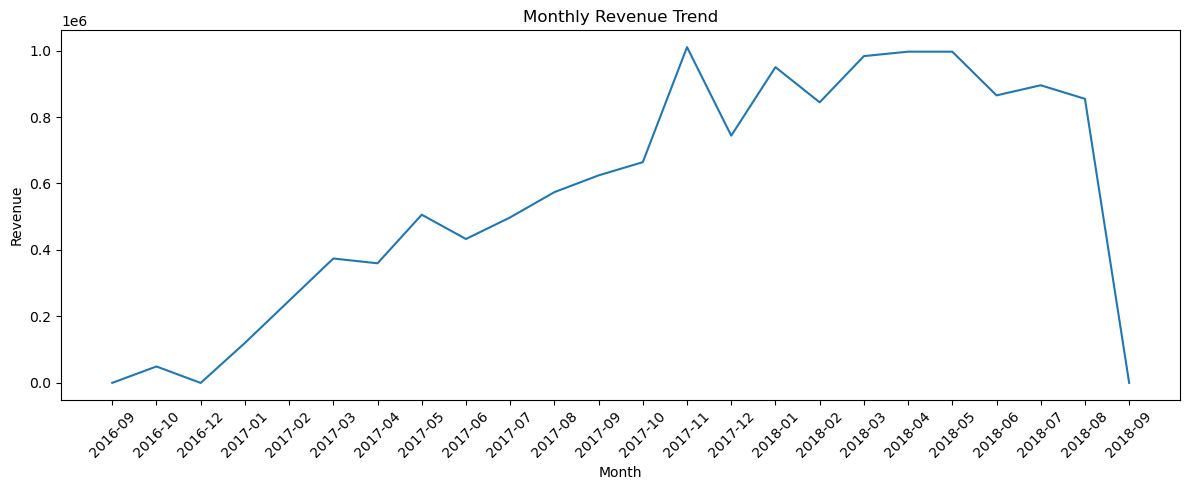

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['order_month'].astype(str),
    monthly_sales['revenue']
)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')

plt.tight_layout()
plt.show()

In [47]:
sales['product_category_name'].isnull().sum()

1603

In [48]:
sales['product_category_name'].nunique()

73

In [49]:
category_sales = (
    sales.groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_sales.head(10)

,product_category_name,price
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


In [50]:
category_sales = category_sales.rename(
    columns={'price': 'revenue'}
)

category_sales.head(10)

,product_category_name,revenue
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


In [51]:
category_sales['revenue_percentage'] = (
    category_sales['revenue']
    / category_sales['revenue'].sum()
) * 100

category_sales.head(10)

,product_category_name,revenue,revenue_percentage
0,beleza_saude,1258681.34,9.384664
1,relogios_presentes,1205005.68,8.984461
2,cama_mesa_banho,1036988.68,7.731735
3,esporte_lazer,988048.97,7.366843
4,informatica_acessorios,911954.32,6.799485
5,moveis_decoracao,729762.49,5.441072
6,cool_stuff,635290.85,4.736696
7,utilidades_domesticas,632248.66,4.714014
8,automotivo,592720.11,4.419291
9,ferramentas_jardim,485256.46,3.618048


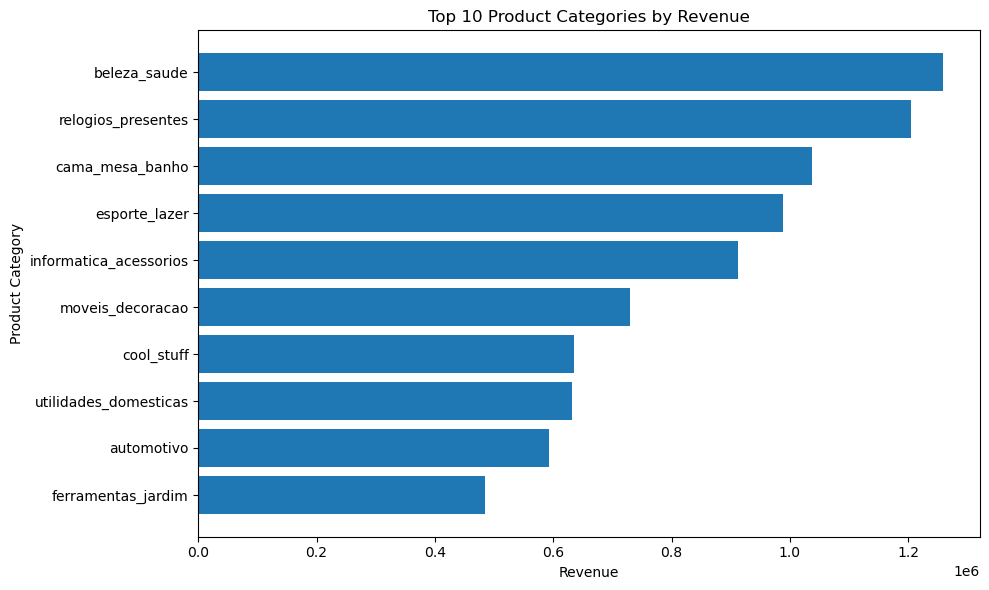

In [52]:
top_10_categories = category_sales.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_categories['product_category_name'],
    top_10_categories['revenue']
)

plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.title('Top 10 Product Categories by Revenue')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [53]:
customers_by_state = (
    customers.groupby('customer_state')['customer_unique_id']
    .nunique()
    .sort_values(ascending=False)
)

customers_by_state.head(10)

customer_state
SP    40302
RJ    12384
MG    11259
RS     5277
PR     4882
SC     3534
BA     3277
DF     2075
ES     1964
GO     1952
Name: customer_unique_id, dtype: int64

In [55]:
customer_revenue =(

sales.groupby('customer_unique_id')['price'].sum().sort_values(ascending=False).reset_index())
customer_revenue.head(10)

,customer_unique_id,price
0,0a0a92112bd4c708ca5fde585afaa872,13440.0
1,da122df9eeddfedc1dc1f5349a1a690c,7388.0
2,763c8b1c9c68a0229c42c9fc6f662b93,7160.0
3,dc4802a71eae9be1dd28f5d788ceb526,6735.0
4,459bef486812aa25204be022145caa62,6729.0
5,ff4159b92c40ebe40454e3e6a7c35ed6,6499.0
6,4007669dec559734d6f53e029e360987,5934.6
7,eebb5dda148d3893cdaf5b5ca3040ccb,4690.0
8,5d0a2980b292d049061542014e8960bf,4599.9
9,48e1ac109decbb87765a3eade6854098,4590.0


In [57]:
customer_revenue.columns

Index(['customer_unique_id', 'price'], dtype='object')

In [58]:
average_customer_revenue = customer_revenue['price'].mean()

print("Average customer revenue:", average_customer_revenue)

Average customer revenue: 142.44019807168308


In [59]:
orders_per_customer = (
    sales.groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index(name='number_of_orders')
)

orders_per_customer.head()

,customer_unique_id,number_of_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [60]:
repeat_customers = orders_per_customer[
    orders_per_customer['number_of_orders'] > 1
]

print("Repeat customers:", len(repeat_customers))

Repeat customers: 2913


In [61]:
repeat_customer_percentage = (
    len(repeat_customers)
    / len(orders_per_customer)
) * 100

print("Repeat customer percentage:", repeat_customer_percentage)

Repeat customer percentage: 3.0528191154894153


In [62]:
orders_per_customer['customer_segment'] = np.select(
    [
        orders_per_customer['number_of_orders'] == 1,
        orders_per_customer['number_of_orders'].between(2, 3),
        orders_per_customer['number_of_orders'] >= 4
    ],
    [
        'One-time',
        'Repeat',
        'Loyal'
    ],
    default='Other'
)

orders_per_customer['customer_segment'].value_counts()

One-time    92507
Repeat       2865
Loyal          48
Name: customer_segment, dtype: int64

#Delivery time analysis

In [63]:
sales["delivery_days"]=(sales['order_delivered_customer_date']-sales['order_purchase_timestamp']).dt.days

In [64]:
sales['delivery_days'].describe()

count    110196.000000
mean         12.007723
std           9.451455
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

In [65]:
sales['delivery_days'].isnull().sum()

2454

In [66]:
sales['delivery_status'] = np.where(
    sales['order_delivered_customer_date'].isna(),
    'Not Delivered',
    np.where(
        sales['order_delivered_customer_date']
        <= sales['order_estimated_delivery_date'],
        'On Time',
        'Late'
    )
)

In [67]:
sales['delivery_status'].value_counts()

On Time          101481
Late               8715
Not Delivered      2454
Name: delivery_status, dtype: int64

In [68]:
delivery_percentage = (
    sales['delivery_status']
    .value_counts(normalize=True)
    * 100
)

delivery_percentage

On Time          90.085220
Late              7.736352
Not Delivered     2.178429
Name: delivery_status, dtype: float64

# customer satisfaction analysis

In [70]:
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")

reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [71]:
reviews.shape
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [72]:
reviews_simple = reviews[['order_id', 'review_score']].copy()

reviews_simple.head()

,order_id,review_score
0,73fc7af87114b39712e6da79b0a377eb,4
1,a548910a1c6147796b98fdf73dbeba33,5
2,f9e4b658b201a9f2ecdecbb34bed034b,5
3,658677c97b385a9be170737859d3511b,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,5


In [73]:
sales_reviews = sales.merge(
    reviews_simple,
    on='order_id',
    how='left'
)

In [74]:
sales_reviews[['order_id', 'delivery_status', 'review_score']].head(10)

,order_id,delivery_status,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,On Time,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,On Time,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,On Time,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,On Time,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,On Time,5.0
5,a4591c265e18cb1dcee52889e2d8acc3,On Time,4.0
6,136cce7faa42fdb2cefd53fdc79a6098,Not Delivered,2.0
7,6514b8ad8028c9f2cc2374ded245783f,On Time,5.0
8,76c6e866289321a7c93b82b54852dc33,On Time,1.0
9,e69bfb5eb88e0ed6a785585b27e16dbf,On Time,5.0


In [75]:
review_by_delivery = (
    sales_reviews
    .groupby('delivery_status')['review_score']
    .mean()
    .sort_values(ascending=False)
)

review_by_delivery

delivery_status
On Time          4.210476
Late             2.548884
Not Delivered    1.762288
Name: review_score, dtype: float64

In [76]:
sales_reviews['review_score'].value_counts().sort_index()

1.0    14235
2.0     3874
3.0     9423
4.0    21315
5.0    63525
Name: review_score, dtype: int64

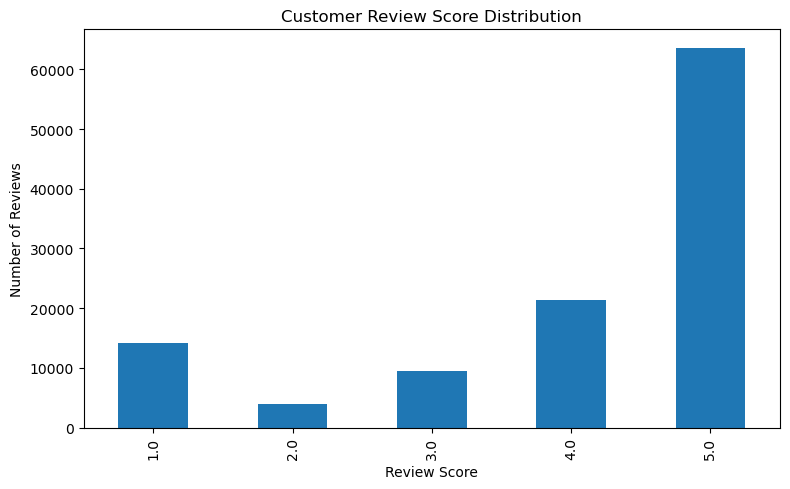

In [77]:
plt.figure(figsize=(8, 5))

sales_reviews['review_score'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.title('Customer Review Score Distribution')

plt.tight_layout()
plt.show()

In [78]:
review_by_delivery
sales_reviews['review_score'].value_counts().sort_index()

1.0    14235
2.0     3874
3.0     9423
4.0    21315
5.0    63525
Name: review_score, dtype: int64

In [79]:
order_analysis = orders.copy()

In [80]:
order_analysis.shape

(99441, 8)

In [81]:
customer_location = customers[
    ['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']
].copy()

In [82]:
order_analysis = order_analysis.merge(
    customer_location,
    on='customer_id',
    how='left'
)

In [83]:
reviews['order_id'].duplicated().sum()

551

In [84]:
order_reviews = (
    reviews.groupby('order_id')['review_score']
    .mean()
    .reset_index()
)

In [85]:
order_analysis = order_analysis.merge(
    order_reviews,
    on='order_id',
    how='left'
)

In [86]:
order_analysis['delivery_status'] = np.where(
    order_analysis['order_delivered_customer_date'].isna(),
    'Not Delivered',
    np.where(
        order_analysis['order_delivered_customer_date']
        <= order_analysis['order_estimated_delivery_date'],
        'On Time',
        'Late'
    )
)

In [87]:
order_analysis['delivery_status'].value_counts()

On Time          88649
Late              7827
Not Delivered     2965
Name: delivery_status, dtype: int64

In [88]:
order_analysis['delivery_days'] = (
    order_analysis['order_delivered_customer_date']
    - order_analysis['order_purchase_timestamp']
).dt.days

In [89]:
order_analysis['delivery_days'].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [90]:
order_analysis.shape

(99441, 14)

In [91]:
order_analysis['delivery_status'].value_counts()

On Time          88649
Late              7827
Not Delivered     2965
Name: delivery_status, dtype: int64

In [92]:
review_by_delivery = (
    order_analysis
    .groupby('delivery_status')['review_score']
    .mean()
    .round(2)
)

review_by_delivery

delivery_status
Late             2.57
Not Delivered    1.75
On Time          4.29
Name: review_score, dtype: float64

In [93]:
delivered_reviews = order_analysis[
    order_analysis['delivery_status'].isin(['On Time', 'Late'])
]

review_comparison = (
    delivered_reviews
    .groupby('delivery_status')['review_score']
    .mean()
    .round(2)
)

review_comparison

delivery_status
Late       2.57
On Time    4.29
Name: review_score, dtype: float64

In [94]:
on_time_score = review_comparison['On Time']
late_score = review_comparison['Late']

difference = round(on_time_score - late_score, 2)

print("On-time average review:", on_time_score)
print("Late average review:", late_score)
print("Difference:", difference)

On-time average review: 4.29
Late average review: 2.57
Difference: 1.72


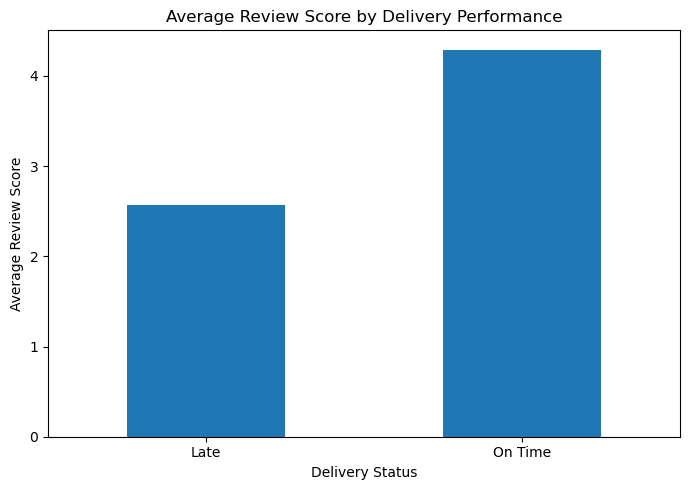

In [95]:
review_comparison.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.title('Average Review Score by Delivery Performance')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [96]:
seller_revenue = (
    sales.groupby('seller_id')
    .agg(
        revenue=('price', 'sum'),
        orders=('order_id', 'nunique')
    )
    .sort_values('revenue', ascending=False)
    .reset_index()
)

seller_revenue.head(10)

,seller_id,revenue,orders
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132
1,53243585a1d6dc2643021fd1853d8905,222776.05,358
2,4a3ca9315b744ce9f8e9374361493884,200472.92,1806
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,982
5,7e93a43ef30c4f03f38b393420bc753a,176431.87,336
6,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314
7,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1160
8,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915
9,955fee9216a65b617aa5c0531780ce60,135171.70,1287


In [97]:
seller_revenue.head(10)

,seller_id,revenue,orders
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132
1,53243585a1d6dc2643021fd1853d8905,222776.05,358
2,4a3ca9315b744ce9f8e9374361493884,200472.92,1806
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,982
5,7e93a43ef30c4f03f38b393420bc753a,176431.87,336
6,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314
7,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1160
8,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915
9,955fee9216a65b617aa5c0531780ce60,135171.70,1287


In [98]:
product_revenue = (
    sales.groupby('product_id')
    .agg(
        revenue=('price', 'sum'),
        units_sold=('order_item_id', 'count'),
        orders=('order_id', 'nunique')
    )
    .sort_values('revenue', ascending=False)
    .reset_index()
)

product_revenue.head(10)

,product_id,revenue,units_sold,orders
0,bb50f2e236e5eea0100680137654686c,63885.00,195,187
1,6cdd53843498f92890544667809f1595,54730.20,156,151
2,d6160fb7873f184099d9bc95e30376af,48899.34,35,35
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51,343,323
4,99a4788cb24856965c36a24e339b6058,43025.56,488,467
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60,274,255
6,25c38557cf793876c5abdd5931f922db,38907.32,38,38
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,63,63
8,53b36df67ebb7c41585e8d54d6772e08,37683.42,323,306
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90,527,431


In [99]:
category_units = (
    sales.groupby('product_category_name')
    .agg(
        revenue=('price', 'sum'),
        units_sold=('order_item_id', 'count')
    )
    .sort_values('units_sold', ascending=False)
    .reset_index()
)

category_units.head(10)

,product_category_name,revenue,units_sold
0,cama_mesa_banho,1036988.68,11115
1,beleza_saude,1258681.34,9670
2,esporte_lazer,988048.97,8641
3,moveis_decoracao,729762.49,8334
4,informatica_acessorios,911954.32,7827
5,utilidades_domesticas,632248.66,6964
6,relogios_presentes,1205005.68,5991
7,telefonia,323667.53,4545
8,ferramentas_jardim,485256.46,4347
9,automotivo,592720.11,4235


In [100]:
category_units['average_price'] = (
    category_units['revenue']
    / category_units['units_sold']
)

category_units.head(10)

,product_category_name,revenue,units_sold,average_price
0,cama_mesa_banho,1036988.68,11115,93.296327
1,beleza_saude,1258681.34,9670,130.163531
2,esporte_lazer,988048.97,8641,114.344285
3,moveis_decoracao,729762.49,8334,87.564494
4,informatica_acessorios,911954.32,7827,116.513903
5,utilidades_domesticas,632248.66,6964,90.788148
6,relogios_presentes,1205005.68,5991,201.135984
7,telefonia,323667.53,4545,71.213978
8,ferramentas_jardim,485256.46,4347,111.630196
9,automotivo,592720.11,4235,139.957523


In [101]:
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")

payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [102]:
payments.shape

(103886, 5)

In [103]:
payments['payment_type'].value_counts()

credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: payment_type, dtype: int64

In [104]:
payment_analysis = (
    payments.groupby('payment_type')
    .agg(
        transactions=('order_id', 'count'),
        revenue=('payment_value', 'sum')
    )
    .sort_values('revenue', ascending=False)
    .reset_index()
)

payment_analysis

,payment_type,transactions,revenue
0,credit_card,76795,12542084.19
1,boleto,19784,2869361.27
2,voucher,5775,379436.87
3,debit_card,1529,217989.79
4,not_defined,3,0.00


In [105]:
payment_analysis['revenue_percentage'] = (
    payment_analysis['revenue']
    / payment_analysis['revenue'].sum()
) * 100

payment_analysis

,payment_type,transactions,revenue,revenue_percentage
0,credit_card,76795,12542084.19,78.344584
1,boleto,19784,2869361.27,17.923569
2,voucher,5775,379436.87,2.370166
3,debit_card,1529,217989.79,1.361681
4,not_defined,3,0.00,0.000000


In [106]:
credit_card = payments[
    payments['payment_type'] == 'credit_card'
]

credit_card['payment_installments'].describe()

count    76795.000000
mean         3.507155
std          2.850990
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         24.000000
Name: payment_installments, dtype: float64

In [107]:
customers.to_csv("../data/customers_cleaned.csv", index=False)

In [108]:
order_items.to_csv("../data/order_items_cleaned.csv", index=False)

In [109]:
products.to_csv("../data/products_cleaned.csv", index=False)

In [110]:
payments.to_csv("../data/payments_cleaned.csv", index=False)

In [111]:
reviews.to_csv("../data/reviews_cleaned.csv", index=False)

In [112]:
order_analysis.to_csv(
    "../data/order_analysis.csv",
    index=False
)